In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# To check min and max polygons

In [ ]:
import geopandas as gpd

def save_min_max_polygons(input_geojson, output_geojson):
    print(f"Loading {input_geojson}...")
    gdf = gpd.read_file(input_geojson)

    gdf = gdf[gdf.geometry.type.isin(['Polygon', 'MultiPolygon'])]

    if gdf.empty:
        print("No polygons found in the GeoJSON.")
        return

    gdf_projected = gdf.to_crs("EPSG:6933")
    gdf['area_hectares'] = gdf_projected.geometry.area / 10000.0

    min_idx = gdf['area_hectares'].idxmin()
    max_idx = gdf['area_hectares'].idxmax()

    filtered_gdf = gdf.loc[[min_idx, max_idx]]

    filtered_gdf.to_file(output_geojson, driver='GeoJSON')

    print(f"Success! Saved only the 2 polygons to: {output_geojson}")
    print(f" - Minimum Area: {gdf.loc[min_idx, 'area_hectares']:.4f} hectares")
    print(f" - Maximum Area: {gdf.loc[max_idx, 'area_hectares']:.4f} hectares")

save_min_max_polygons('/content/drive/MyDrive/Thesis/DataSet/target_data.geojson', 'min_max_only.geojson')

# To plot distribution of 3 continuous variables

Loading GeoPackages...


/tmp/ipykernel_13489/991740431.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Timber_Stock_Class'] = pd.cut(df1['stock_per_ha'], bins=bins, labels=labels)


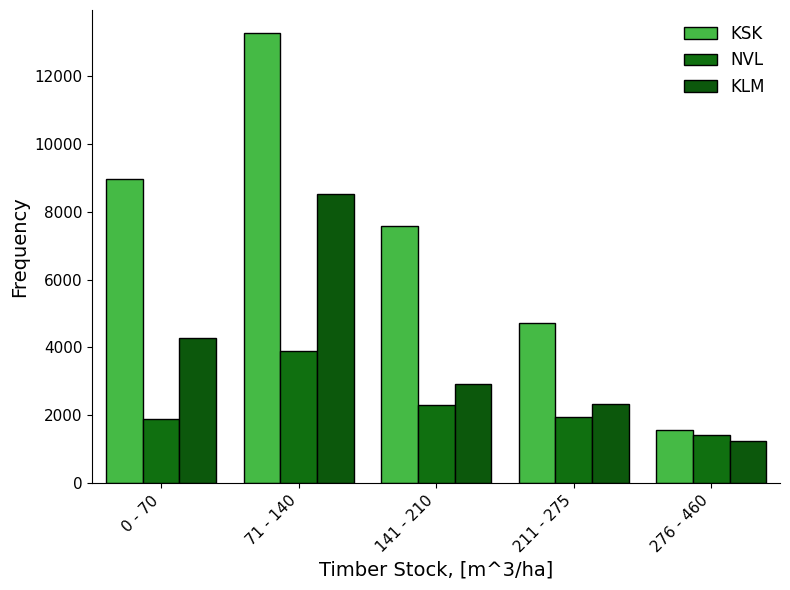

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

NVL_GPKG = '/content/drive/MyDrive/Thesis/DataSet/NVL_Polygons.gpkg'
KSK_GPKG = '/content/drive/MyDrive/Thesis/DataSet/KSK_Polygons.gpkg'
KLM_GPKG = '/content/drive/MyDrive/Thesis/DataSet/KLM_Polygons.gpkg'

print("Loading GeoPackages...")

gdf_nvl = gpd.read_file(NVL_GPKG)
gdf_nvl['Forest'] = 'NVL'

gdf_ksk = gpd.read_file(KSK_GPKG)
gdf_ksk['Forest'] = 'KSK'

gdf_klm = gpd.read_file(KLM_GPKG)
gdf_klm['Forest'] = 'KLM'

df = pd.concat([
    pd.DataFrame(gdf_nvl.drop(columns='geometry')),
    pd.DataFrame(gdf_ksk.drop(columns='geometry')),
    pd.DataFrame(gdf_klm.drop(columns='geometry'))
], ignore_index=True)
df1 = df.loc[df["age"] != 5]

bins = [-0.1, 69, 138, 207, 276, 460]
labels = ['0 - 70', '71 - 140', '141 - 210', '211 - 275', '276 - 460']

df1['Timber_Stock_Class'] = pd.cut(df1['stock_per_ha'], bins=bins, labels=labels)

plt.figure(figsize=(8, 6))

# Specific colors mapped to your forests
forest_palette = {'KSK': 'limegreen', 'NVL': 'green', 'KLM': 'darkgreen'}

ax = sns.countplot(
    data=df1,
    x='Timber_Stock_Class',
    hue='Forest',
    palette=forest_palette,
    edgecolor='black', # Black outline
    linewidth=1,
    hue_order=['KSK', 'NVL', 'KLM']
)

plt.xlabel('Timber Stock, [m^3/ha]', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.legend(title=None, frameon=False, fontsize=12)
sns.despine()

plt.tight_layout()

plt.show()

# To plot class variables


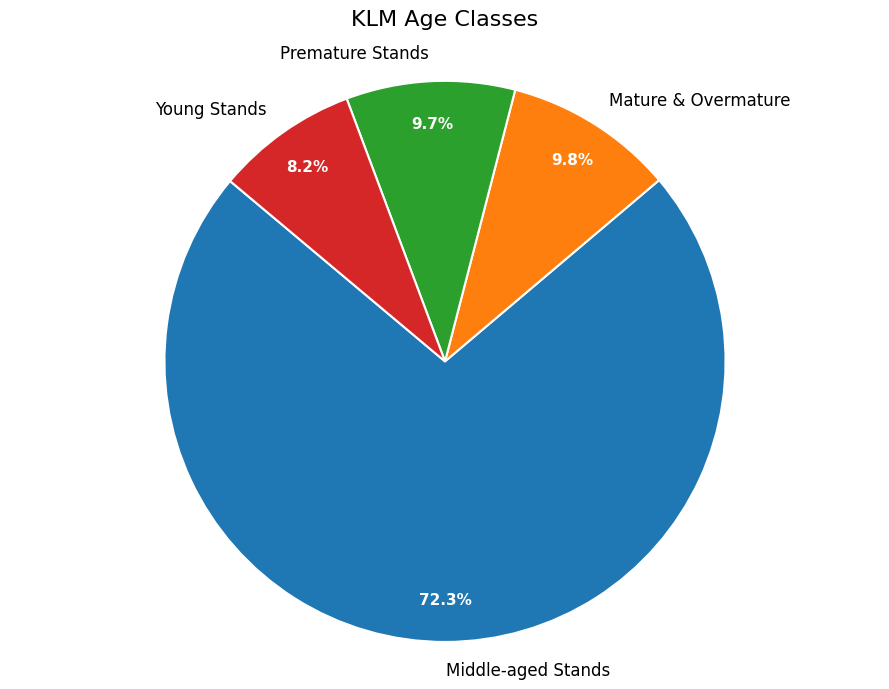

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd

NVL_GPKG = '/content/drive/MyDrive/Thesis/DataSet/NVL_Polygons.gpkg'
KSK_GPKG = '/content/drive/MyDrive/Thesis/DataSet/KSK_Polygons.gpkg'
KLM_GPKG = '/content/drive/MyDrive/Thesis/DataSet/KLM_Polygons.gpkg'
df = gpd.read_file(KLM_GPKG)

age_class_mapping = {
    1: 'Young Stands',
    2: 'Middle-aged Stands',
    3: 'Premature Stands',
    4: 'Mature & Overmature'
    # 5: 'No-forest & Very young'
}
df['age_name'] = df['age'].map(age_class_mapping)
df1 = df.loc[df["age"] != 5]

age_counts = df1['age_name'].value_counts()

# Set up the figure size
plt.figure(figsize=(9, 7))

# Create the pie chart
wedges, texts, autotexts = plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=140,              # Rotates the chart so it doesn't start at a harsh 0 degrees
    pctdistance=0.85,            # Distance of percentage text from center
    labeldistance=1.1,           # Distance of category labels from center
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} # Adds clean white lines between slices
)

# Make the text easy to read
plt.setp(texts, size=12)         # Category label font size
plt.setp(autotexts, size=11, weight="bold", color="white") # Percentage text styling



# Add a title
plt.title('KLM Age Classes', fontsize=16, pad=20)

# Ensure it's perfectly circular
plt.axis('equal')

plt.tight_layout()

# # Save the plot
# output_plot = '/content/drive/MyDrive/Thesis/Plots/Age_Class_Pie_Chart.png'
# plt.savefig(output_plot, dpi=300)
# print(f"Plot saved successfully to {output_plot}")

plt.show()